## 1. Import Necessary Libraries

In [4]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

import warnings
warnings.filterwarnings("ignore")

## 2. Import Dataset

In [5]:
cars_data=pd.read_csv(filepath_or_buffer = "Cars.csv")
cars_data

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


## 3. Data Understanding

### 3.1 Perform initial investigation on the Data

In [6]:
cars_data.shape

(81, 5)

In [7]:
cars_data.isnull().sum()

HP     0
MPG    0
VOL    0
SP     0
WT     0
dtype: int64

In [8]:
cars_data.dtypes

HP       int64
MPG    float64
VOL      int64
SP     float64
WT     float64
dtype: object

In [9]:
cars_data.isna().sum()

HP     0
MPG    0
VOL    0
SP     0
WT     0
dtype: int64

In [10]:
cars_data.describe()

,HP,MPG,VOL,SP,WT
count,81.000000,81.000000,81.000000,81.000000,81.000000
mean,117.469136,34.422076,98.765432,121.540272,32.412577
std,57.113502,9.131445,22.301497,14.181432,7.492813
min,49.000000,12.101263,50.000000,99.564907,15.712859
25%,84.000000,27.856252,89.000000,113.829145,29.591768
50%,100.000000,35.152727,101.000000,118.208698,32.734518
75%,140.000000,39.531633,113.000000,126.404312,37.392524
max,322.000000,53.700681,160.000000,169.598513,52.997752


# Now let's check for the Assumptions

## TEST 1 : Linearity Test

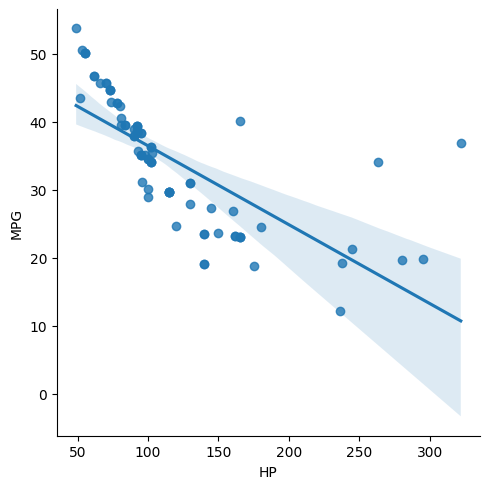

In [11]:
sns.lmplot(cars_data,x="HP",y="MPG",)

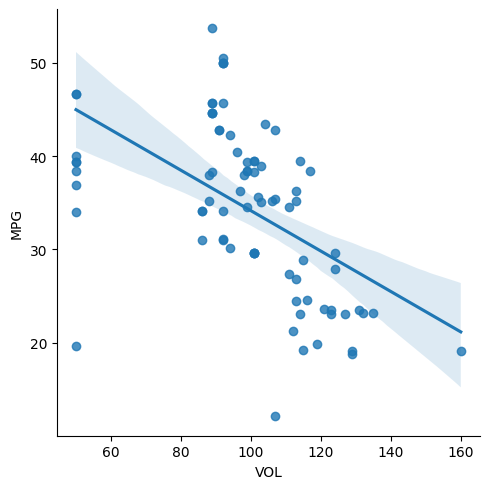

In [12]:
 sns.lmplot(cars_data,x="VOL",y="MPG",)

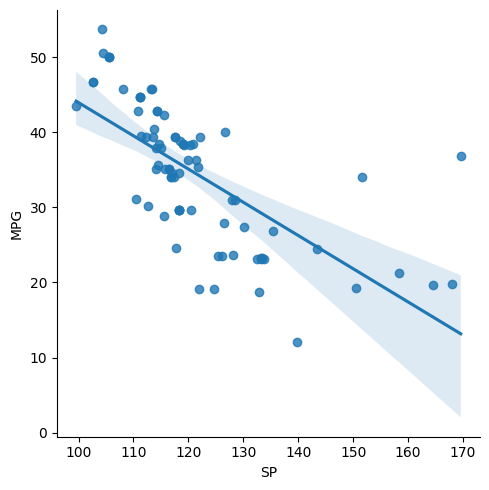

In [13]:
sns.lmplot(cars_data,x="SP",y="MPG",)

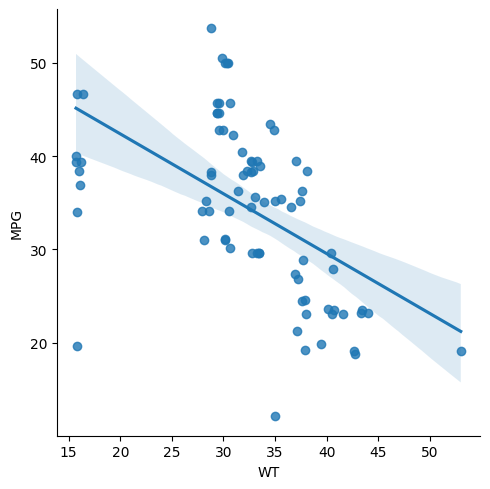

In [14]:
sns.lmplot(cars_data,x="WT",y="MPG",)

### TEST 1 : Linearity Test **FAILED**

## TEST 2 : Normality Test

(array([15., 35.,  9.,  6.,  9.,  0.,  2.,  2.,  1.,  2.]),
 array([ 49. ,  76.3, 103.6, 130.9, 158.2, 185.5, 212.8, 240.1, 267.4,
        294.7, 322. ]),
 <BarContainer object of 10 artists>)

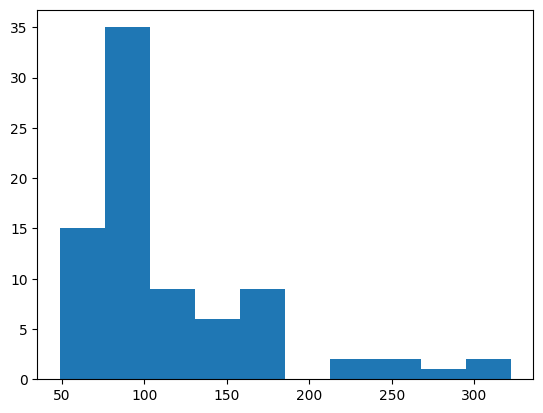

In [15]:
plt.hist(cars_data ["HP"])

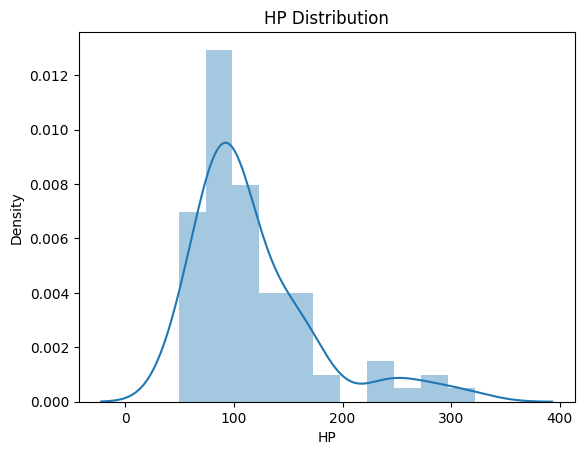

In [16]:
sns.distplot(a=cars_data["HP"])
plt.title("HP Distribution")
plt.show()

(array([ 8., 12., 32., 10., 10.,  2.,  1.,  2.,  1.,  3.]),
 array([ 99.56490661, 106.56826723, 113.57162785, 120.57498847,
        127.57834909, 134.58170971, 141.58507032, 148.58843094,
        155.59179156, 162.59515218, 169.5985128 ]),
 <BarContainer object of 10 artists>)

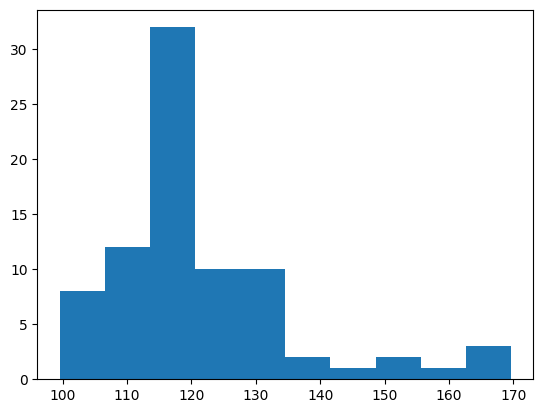

In [17]:
plt.hist(cars_data ["SP"])

(array([ 9.,  0.,  0., 22., 20., 15.,  8.,  6.,  0.,  1.]),
 array([ 50.,  61.,  72.,  83.,  94., 105., 116., 127., 138., 149., 160.]),
 <BarContainer object of 10 artists>)

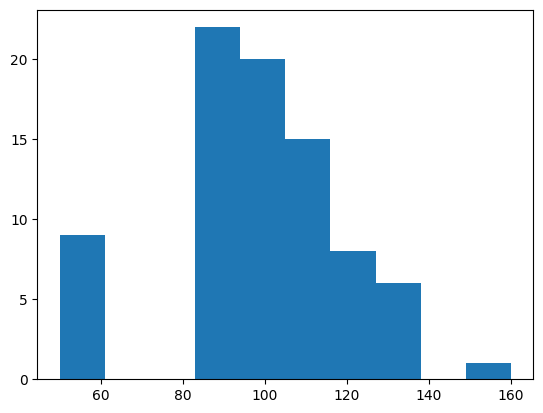

In [18]:
plt.hist(cars_data ["VOL"])

(array([ 9.,  0.,  0., 22., 19., 18.,  7.,  5.,  0.,  1.]),
 array([15.71285853, 19.44134791, 23.1698373 , 26.89832668, 30.62681606,
        34.35530544, 38.08379483, 41.81228421, 45.54077359, 49.26926298,
        52.99775236]),
 <BarContainer object of 10 artists>)

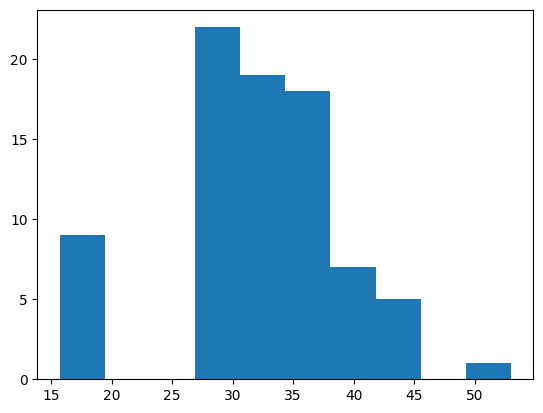

In [19]:
plt.hist(cars_data ["WT"])

### TEST 2 : Normality Test **FAILED**

## TEST 3 : Multi-collinearity Test

In [20]:
corr_matrix=cars_data.corr()
corr_matrix

,HP,MPG,VOL,SP,WT
HP,1.000000,-0.725038,0.077459,0.973848,0.076513
MPG,-0.725038,1.000000,-0.529057,-0.687125,-0.526759
VOL,0.077459,-0.529057,1.000000,0.102170,0.999203
SP,0.973848,-0.687125,0.102170,1.000000,0.102439
WT,0.076513,-0.526759,0.999203,0.102439,1.000000


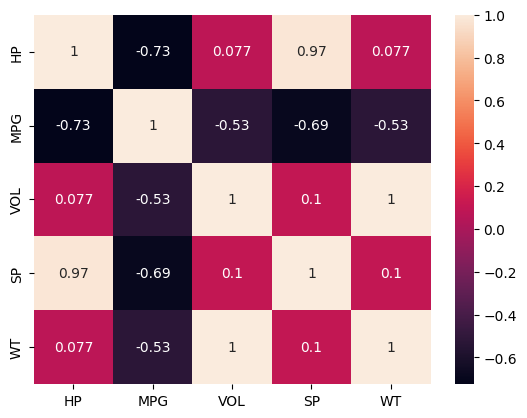

In [21]:
sns.heatmap(corr_matrix,annot=True)
plt.show()

### Test 3 - There is Multi-collinearity  in the Data

## Test 4 AutoRegression Passed

# 4. Data Preparation
There is nothing to prepare because all features are numeric feature engineering techniques can be applied here

In [22]:
cars_data

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


In [23]:
x=cars_data[["HP","VOL","SP","WT"]]
x

,HP,VOL,SP,WT
0,49,89,104.185353,28.762059
1,55,92,105.461264,30.466833
2,55,92,105.461264,30.193597
3,70,92,113.461264,30.632114
4,53,92,104.461264,29.889149
...,...,...,...,...
76,322,50,169.598513,16.132947
77,238,115,150.576579,37.923113
78,263,50,151.598513,15.769625
79,295,119,167.944460,39.423099


In [24]:
y=cars_data["MPG"]
y

0     53.700681
1     50.013401
2     50.013401
3     45.696322
4     50.504232
        ...    
76    36.900000
77    19.197888
78    34.000000
79    19.833733
80    12.101263
Name: MPG, Length: 81, dtype: float64

# 5. Model Building

In [25]:
Linear_Model=LinearRegression()

# 6. Model Training

In [26]:
Linear_Model.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
Linear_Model.intercept_

np.float64(30.67733585215165)

In [28]:
Linear_Model.coef_

array([-0.20544372, -0.33605084,  0.39562692,  0.40057409])

# 7. Model Testing

In [29]:
y_predicted=Linear_Model.predict(x)
y_predicted

array([43.44193477, 42.38879289, 42.27934147, 42.53835981, 42.17264802,
       43.02061916, 42.32536062, 48.07621852, 48.28120247, 40.79122814,
       41.52153227, 47.80956747, 39.95980269, 41.52757889, 41.76632332,
       41.6181448 , 41.15094046, 47.98605515, 41.30861046, 37.87127922,
       38.57706414, 37.35199705, 37.89770285, 39.5625144 , 39.93380662,
       46.73870908, 35.48165898, 38.78152504, 38.24861192, 36.00285298,
       34.84603989, 37.21630246, 37.13919796, 34.82541399, 37.22361389,
       37.53950097, 39.27144845, 38.24219888, 38.54286458, 35.9391722 ,
       34.2129755 , 35.36313259, 37.50473376, 38.07998482, 35.79651664,
       36.2613377 , 34.21826465, 35.59393404, 36.91805291, 33.31108154,
       33.21313413, 33.3023649 , 29.19864884, 27.52358579, 28.3207133 ,
       28.56722621, 35.81583602, 33.02108459, 35.37334971, 32.29909503,
       29.87685849, 28.76093817, 25.14188416, 26.47040896, 25.97651933,
       36.35652478, 26.0975912 , 23.6416178 , 24.39887199, 20.21

# 8. Model Evalution

In [30]:
error=y-y_predicted
error

0     10.258747
1      7.624608
2      7.734060
3      3.157963
4      8.331584
        ...    
76    15.617904
77     1.298838
78     7.863547
79     7.517122
80    -3.458218
Name: MPG, Length: 81, dtype: float64

In [31]:
error.mean()

np.float64(3.50885301609926e-16)

In [51]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

### Mean Absolute Error
same units

from predicted results the mean absolute error value 3.26 changes

In [44]:
mean_absolute_error(y,y_predicted)

3.267968285420799

### Mean Squared Error
from predicted results the value will be squared 

In [46]:
mean_squared_error(y,y_predicted)

18.8971411523431

### Root Mean Square Error
Normalizing the units

In [48]:
root_mean_squared_error(y,y_predicted)

4.347084212704315

### R2 Score
to give output how much does it contributes 

In [50]:
r2_score(y,y_predicted)

0.7705372737359844

### Adjusted R2 Score

In [52]:
import statsmodels.formula.api as smf

In [53]:
cars_data.head()

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149


In [55]:
linear_stats_model=smf.ols(formula="MPG ~ HP+VOL+SP+WT",data=cars_data).fit()

In [57]:
print("R2 Score:",linear_stats_model.rsquared.round(4),"\nAdjusted R2 Score:",linear_stats_model.rsquared_adj.round(4))

R2 Score: 0.7705 
Adjusted R2 Score: 0.7585


In [60]:
linear_stats_model=smf.ols(formula="MPG ~ HP",data=cars_data).fit()

In [61]:
print("R2 Score:",linear_stats_model.rsquared.round(4),"\nAdjusted R2 Score:",linear_stats_model.rsquared_adj.round(4))

R2 Score: 0.5257 
Adjusted R2 Score: 0.5197


In [62]:
linear_stats_model=smf.ols(formula="MPG ~ HP+VOL",data=cars_data).fit()

In [63]:
print("R2 Score:",linear_stats_model.rsquared.round(4),"\nAdjusted R2 Score:",linear_stats_model.rsquared_adj.round(4))

R2 Score: 0.7507 
Adjusted R2 Score: 0.7443


In [65]:
linear_stats_model=smf.ols(formula="MPG ~ HP+VOL+SP",data=cars_data).fit()

In [66]:
print("R2 Score:",linear_stats_model.rsquared.round(4),"\nAdjusted R2 Score:",linear_stats_model.rsquared_adj.round(4))

R2 Score: 0.7704 
Adjusted R2 Score: 0.7614


In [67]:
linear_stats_model=smf.ols(formula="MPG ~ HP+VOL+SP+WT",data=cars_data).fit()

In [68]:
print("R2 Score:",linear_stats_model.rsquared.round(4),"\nAdjusted R2 Score:",linear_stats_model.rsquared_adj.round(4))

R2 Score: 0.7705 
Adjusted R2 Score: 0.7585


## Let's perform TEST 5 HOMOSCEDASTICITY TEST

In [32]:
cars_data["error"]=error
cars_data

,HP,MPG,VOL,SP,WT,error
0,49,53.700681,89,104.185353,28.762059,10.258747
1,55,50.013401,92,105.461264,30.466833,7.624608
2,55,50.013401,92,105.461264,30.193597,7.734060
3,70,45.696322,92,113.461264,30.632114,3.157963
4,53,50.504232,92,104.461264,29.889149,8.331584
...,...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947,15.617904
77,238,19.197888,115,150.576579,37.923113,1.298838
78,263,34.000000,50,151.598513,15.769625,7.863547
79,295,19.833733,119,167.944460,39.423099,7.517122


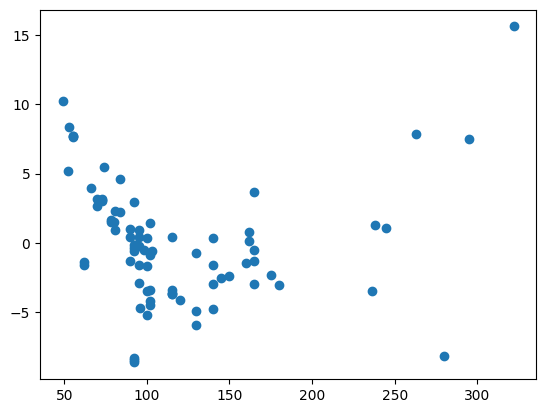

In [33]:
plt.scatter(data=cars_data,x="HP",y="error")

In [34]:
del cars_data["error"]
cars_data

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


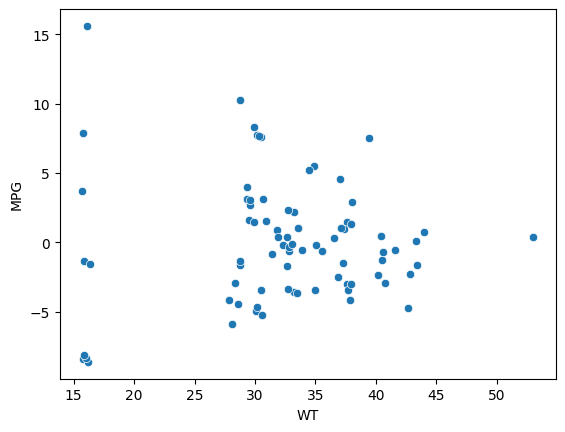

In [35]:
sns.scatterplot(data=cars_data,x="WT",y=error)
plt.show()

### TEST 5 : HOMOSCEDASTICITY TEST also **FAILED**

## TEST 6 : Zero Residual Mean Test

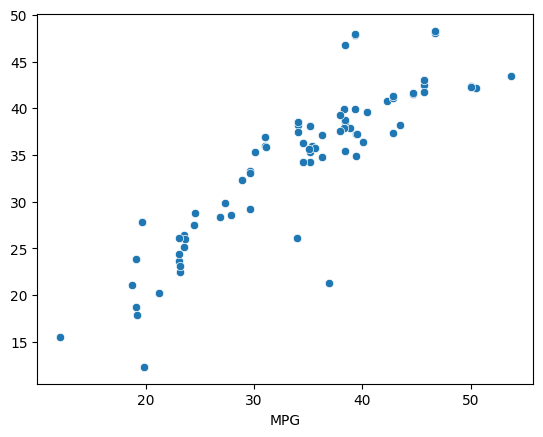

In [36]:
sns.scatterplot(data=cars_data,x="MPG",y=y_predicted)
plt.show()

### Test 6: Zero Residual Mean Test is also **Failed**

# 9. Model Deployment

In [37]:
from pickle import dump

In [38]:
dump(obj = Linear_Model, file = open(file = "limear_intelligence_file.pkl", mode="wb"))

In [39]:
from pickle import load


In [40]:
linear_intel_pkl = load(file = open(file = "limear_intelligence_file.pkl", mode="rb"))
linear_intel_pkl

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [41]:
linear_intel_pkl.predict(x)                                    

array([43.44193477, 42.38879289, 42.27934147, 42.53835981, 42.17264802,
       43.02061916, 42.32536062, 48.07621852, 48.28120247, 40.79122814,
       41.52153227, 47.80956747, 39.95980269, 41.52757889, 41.76632332,
       41.6181448 , 41.15094046, 47.98605515, 41.30861046, 37.87127922,
       38.57706414, 37.35199705, 37.89770285, 39.5625144 , 39.93380662,
       46.73870908, 35.48165898, 38.78152504, 38.24861192, 36.00285298,
       34.84603989, 37.21630246, 37.13919796, 34.82541399, 37.22361389,
       37.53950097, 39.27144845, 38.24219888, 38.54286458, 35.9391722 ,
       34.2129755 , 35.36313259, 37.50473376, 38.07998482, 35.79651664,
       36.2613377 , 34.21826465, 35.59393404, 36.91805291, 33.31108154,
       33.21313413, 33.3023649 , 29.19864884, 27.52358579, 28.3207133 ,
       28.56722621, 35.81583602, 33.02108459, 35.37334971, 32.29909503,
       29.87685849, 28.76093817, 25.14188416, 26.47040896, 25.97651933,
       36.35652478, 26.0975912 , 23.6416178 , 24.39887199, 20.21